In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.image import imread
from PIL import Image
import cv2
import shutil
import numpy as np
from tqdm import tqdm
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adamax, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

import warnings
warnings.filterwarnings('ignore')

In [20]:
train_path = Path("/kaggle/input/augmented_train_300")
valid_path = Path("/kaggle/input/validation_dataset_300")
test_path = Path("/kaggle/input/test_dataset_300")

In [22]:
image_size = 256
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 96

In [23]:
def count_ext(root, ext):
    ext = ext.lower()
    return sum(
        1 for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() == ext
    )

print("jpeg:", count_ext(train_path, ".jpeg"))

jpeg: 0


In [24]:
IMG_EXTS = {".jpg"}

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def count_images_recursive(path: Path):
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_images_in_dir(path: Path):
    return sum(1 for p in path.iterdir() if p.suffix.lower() in IMG_EXTS)

In [25]:
def make_df(pharaohs_path: Path):
    rows = []

    for class_dir in list_subdirs(pharaohs_path):
        pharaoh_name = class_dir.name
        for p in class_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                rows.append({"label": str(pharaoh_name)  , "path": str(p)})

    df = pd.DataFrame(rows, columns=["label", "path"])
    return df

In [26]:
train_df = make_df(train_path)
valid_df = make_df(valid_path)
test_df = make_df(test_path)

In [27]:
train_df.sample(10)

,label,path
3054,Amun_and_Mut_(God_and_Goddess),/kaggle/input/augmented_train_300/Amun_and_Mut...
11039,Psusennes_I,/kaggle/input/augmented_train_300/Psusennes_I/...
9315,Nectanebo_II_and_God_Horus,/kaggle/input/augmented_train_300/Nectanebo_II...
13525,Ramesses_II_and_God_Ptah_and_Goddess_Sekhment,/kaggle/input/augmented_train_300/Ramesses_II_...
2055,Amenhotep_III_and_God_Re-Horakhty,/kaggle/input/augmented_train_300/Amenhotep_II...
8935,"Mutnofret_(Queen,_Wife_of_Thutmose_I_and_mothe...",/kaggle/input/augmented_train_300/Mutnofret_(Q...
17064,Sneferu,/kaggle/input/augmented_train_300/Sneferu/147_...
16120,Seti_I,/kaggle/input/augmented_train_300/Seti_I/159_a...
2201,Amenhotep_III_and_Wife_Queen_Tiye,/kaggle/input/augmented_train_300/Amenhotep_II...
20107,Yuya_(father_of_Queen_Tiye),/kaggle/input/augmented_train_300/Yuya_(father...


In [28]:
print("Dataframe shape:", train_df.shape)

Dataframe shape: (20210, 2)


<Axes: xlabel='label', ylabel='count'>

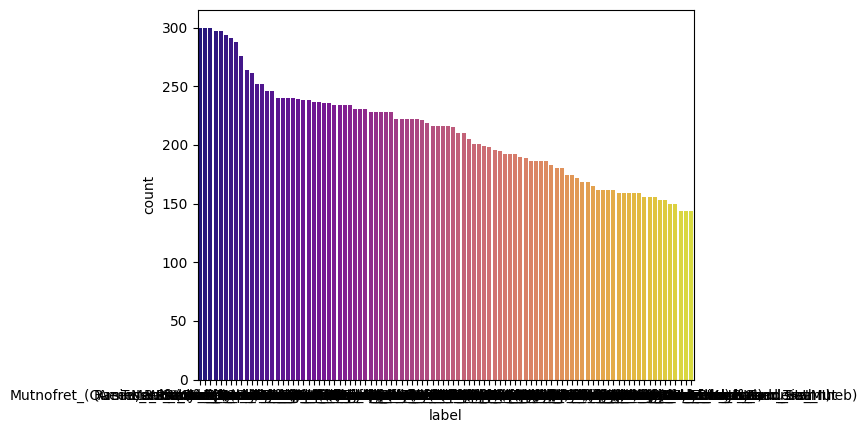

In [29]:
sns.countplot(data=train_df,x='label',palette='plasma',order=train_df['label'].value_counts().index )

In [30]:
train_df['label'].value_counts()

label
Hor_I                                       300
Seti_I                                      300
Ramesses_II_and_Goddess_Anath               300
Amenhotep_III                               297
Ptah_(God)                                  297
                                           ... 
Ramesess_II_and_God_Amun_and_Goddess_Mut    150
Ramesses_III_and_Gods_Horus_and_Seth        150
Isis_(Goddess)                              144
Ptolemy_III_Euergetes                       144
Thutmose_IV_and_his_mother_Tiaa             144
Name: count, Length: 96, dtype: int64

In [31]:
def show(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_bgr(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read {path}")
    return img_bgr

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [32]:
def resize(image, size=image_size):
  return cv2.resize(image,(size,size), interpolation=cv2.INTER_AREA)
    
def normalize(image):
  return image/255.0

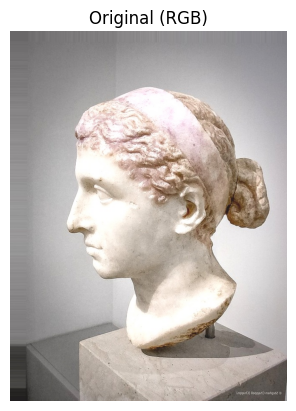

Original shape: (855, 640, 3) dtype: uint8


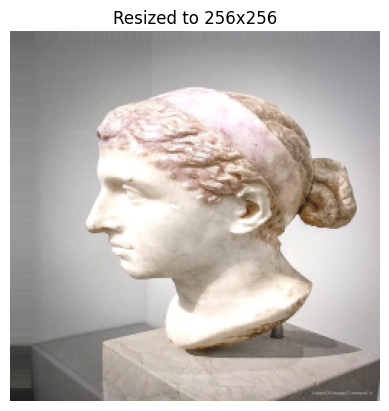

Resized shape: (256, 256, 3)


In [33]:
sample_row = train_df.iloc[3901]
sample_path = sample_row["path"]
sample_label = sample_row["label"]

image_BGR = load_bgr(sample_path)
image_RGB = bgr_to_rgb(image_BGR)

show("Original (RGB)", image_RGB)
print("Original shape:", image_RGB.shape, "dtype:", image_RGB.dtype)

image_resized= resize(image_RGB,image_size)
show(f"Resized to {image_size}x{image_size}", image_resized)
print("Resized shape:", image_resized.shape)


In [ ]:
def preprocess_image(path, size=image_size, augment=False):
    image_BGR = load_bgr(path)
    image_RGB = bgr_to_rgb(image_BGR)
    image_resized = resize(image_RGB, size)

    if augment:
        image_processed = apply_augmentation(image_resized)
    else:
        image_processed = image_resized

    return image_processed

In [36]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class TFDataset:
    def __init__(self, df, augment=False, batch_size=BATCH_SIZE, shuffle=True, image_size=image_size):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(
                path_str,
                size=self.image_size,
                augment=self.augment
            )
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label"].values.astype("float32")

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

In [37]:
print("Train size:", train_df.shape[0])
print("Test size:", test_df['label'].shape[0])
print("Valid size:", valid_df['label'].shape[0])

Train size: 20210
Test size: 599
Valid size: 1395


In [38]:
encoder = LabelEncoder()

train_df['label'] = encoder.fit_transform(train_df['label'])
test_df['label'] = encoder.transform(test_df['label'])
valid_df['label'] = encoder.transform(valid_df['label'])

In [ ]:
counts = train_df['label'].value_counts()
counts.index = encoder.inverse_transform(counts.index.astype(int))
counts

Hor_I                                       300
Seti_I                                      300
Ramesses_II_and_Goddess_Anath               300
Amenhotep_III                               297
Ptah_(God)                                  297
                                           ... 
Ramesess_II_and_God_Amun_and_Goddess_Mut    150
Ramesses_III_and_Gods_Horus_and_Seth        150
Isis_(Goddess)                              144
Ptolemy_III_Euergetes                       144
Thutmose_IV_and_his_mother_Tiaa             144
Name: count, Length: 96, dtype: int64

In [40]:
train_df['label'].values

array([ 0,  0,  0, ..., 95, 95, 95])

In [41]:
y = train_df['label'] 

classes = np.unique(y)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights_array))

print(class_weights)

{np.int64(0): np.float64(0.9482920420420421), np.int64(1): np.float64(1.2531001984126984), np.int64(2): np.float64(0.8771701388888888), np.int64(3): np.float64(1.3240303983228512), np.int64(4): np.float64(1.1695601851851851), np.int64(5): np.float64(0.7627566425120773), np.int64(6): np.float64(0.9525829562594268), np.int64(7): np.float64(0.892037429378531), np.int64(8): np.float64(0.708824354657688), np.int64(9): np.float64(1.1318324372759856), np.int64(10): np.float64(0.8996616809116809), np.int64(11): np.float64(1.3494925213675213), np.int64(12): np.float64(1.1318324372759856), np.int64(13): np.float64(1.0964626736111112), np.int64(14): np.float64(1.079594017094017), np.int64(15): np.float64(1.2758838383838385), np.int64(16): np.float64(0.8996616809116809), np.int64(17): np.float64(0.9612823439878234), np.int64(18): np.float64(0.9482920420420421), np.int64(19): np.float64(0.7160572562358276), np.int64(20): np.float64(1.1138668430335097), np.int64(21): np.float64(0.9791666666666666), 

In [45]:
train_data = TFDataset(
    train_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=True,
    image_size=256)

val_data = TFDataset(
    valid_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=256
)

In [46]:
print("Number of samples:", len(train_data.df))
print("Number of batches:", len(train_data))

Number of samples: 20210
Number of batches: 632


In [52]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(256, 256, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,069,856 (11.71 MB)

 Trainable params: 811,872 (3.10 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [53]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,069,856 (11.71 MB)

 Trainable params: 811,872 (3.10 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [54]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [55]:
history = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]

Epoch 1/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 712s 1s/step - accuracy: 0.0700 - loss: 4.3346 - val_accuracy: 0.5857 - val_loss: 2.4043 - learning_rate: 1.0000e-04
Epoch 2/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 691s 1s/step - accuracy: 0.4613 - loss: 2.3783 - val_accuracy: 0.7226 - val_loss: 1.3420 - learning_rate: 1.0000e-04
Epoch 3/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.6420 - loss: 1.4837 - val_accuracy: 0.8029 - val_loss: 0.9433 - learning_rate: 1.0000e-04
Epoch 4/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - accuracy: 0.7280 - loss: 1.0985 - val_accuracy: 0.8358 - val_loss: 0.7395 - learning_rate: 1.0000e-04
Epoch 5/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 704s 1s/step - accuracy: 0.7900 - loss: 0.8352 - val_accuracy: 0.8681 - val_loss: 0.5920 - learning_rate: 1.0000e-04
Epoch 6/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 714s 1s/step - accuracy: 0.8289 - loss: 0.6671 - val_accuracy: 0.8896 - val_loss: 0.4996 - learning_rate: 1.0000e-04
Epoch 7/10
632/632 ━━━━━━━━━━━━━━━━━━━━ 771s 1s/step - acc

In [ ]:
base_model.trainable = True 

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history_finetune = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20


2026-02-02 19:21:21.110549: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 19:21:21.307912: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.6395 - loss: 1.4492

2026-02-02 19:32:17.188727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 19:32:17.387883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


632/632 ━━━━━━━━━━━━━━━━━━━━ 796s 1s/step - accuracy: 0.6397 - loss: 1.4480 - val_accuracy: 0.1262 - val_loss: 8.8997 - learning_rate: 0.0010
Epoch 2/20
632/632 ━━━━━━━━━━━━━━━━━━━━ 717s 1s/step - accuracy: 0.8495 - loss: 0.5828 - val_accuracy: 0.0315 - val_loss: 15.3286 - learning_rate: 0.0010
Epoch 3/20
632/632 ━━━━━━━━━━━━━━━━━━━━ 704s 1s/step - accuracy: 0.8818 - loss: 0.4581 - val_accuracy: 0.0703 - val_loss: 13.1070 - learning_rate: 0.0010
Epoch 4/20
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8977 - loss: 0.4038
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
632/632 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.8977 - loss: 0.4038 - val_accuracy: 0.1118 - val_loss: 10.5906 - learning_rate: 0.0010
Epoch 5/20
632/632 ━━━━━━━━━━━━━━━━━━━━ 763s 1s/step - accuracy: 0.9546 - loss: 0.1594 - val_accuracy: 0.8022 - val_loss: 0.8390 - learning_rate: 3.0000e-04
Epoch 6/20
632/632 ━━━━━━━━━━━━━━━━━━━━ 753s 1s/step - accuracy: 0.9839 - loss: 0.0531 - 

Text(0.5, 1.0, 'Model Accuracy during Training')

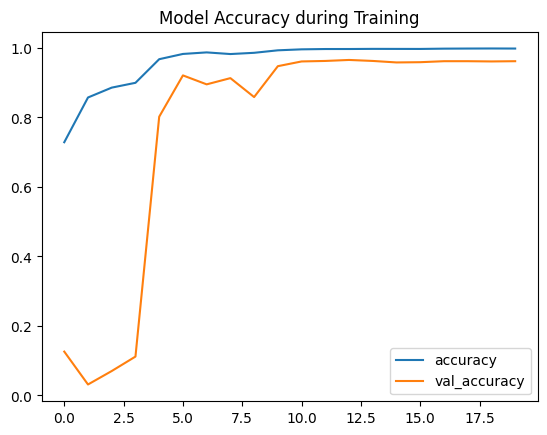

In [61]:
losses=pd.DataFrame(history_finetune.history)
losses[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy during Training')

Text(0.5, 1.0, 'Model Loss during Training')

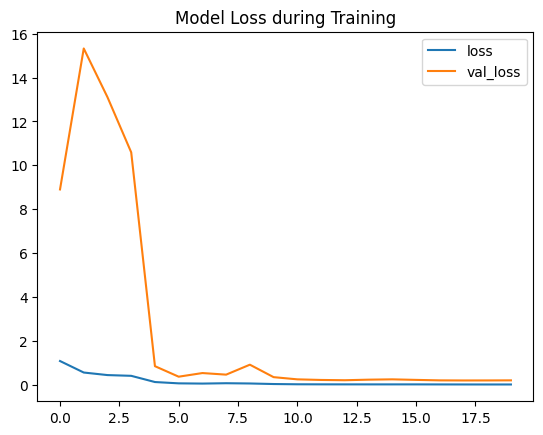

In [62]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss during Training')

In [63]:
val_loss, val_accuracy=model.evaluate(val_data.dataset)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9634 - loss: 0.1741
Validation Loss: 0.1873
Validation Accuracy: 0.9620


In [66]:
test_data = TFDataset(
    test_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size,
)

In [67]:
print("Number of samples:", len(test_data.df))
print("Number of batches:", len(test_data))

Number of samples: 599
Number of batches: 19


In [68]:
y_true = np.concatenate([y for x, y in val_data.dataset], axis=0)
y_pred = np.argmax(model.predict(val_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        13
         1.0       0.83      1.00      0.91         5
         2.0       1.00      0.93      0.96        42
         3.0       0.78      0.78      0.78         9
         4.0       1.00      1.00      1.00         5
         5.0       1.00      1.00      1.00         8
         6.0       1.00      0.95      0.97        39
         7.0       0.95      1.00      0.98        41
         8.0       0.94      0.97      0.96        34
         9.0       1.00      1.00      1.00        11
        10.0       1.00      1.00      1.00        14
        11.0       1.00      1.00      1.00         9
        12.0       1.00      1.00      1.00         5
        13.0       1.00      0.83      0.91         6
        14.0       1.00      1.00      1.00        11
        15.0       0.90      0.90      0.90        10
        16.0       0.75      1.00      0.8

In [69]:
test_loss, test_accuracy=model.evaluate(test_data.dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9792 - loss: 0.1094
Test Loss: 0.1578
Test Accuracy: 0.9716


In [70]:
y_true = np.concatenate([y for x, y in test_data.dataset], axis=0)
y_pred = np.argmax(model.predict(test_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         6
         1.0       1.00      1.00      1.00         2
         2.0       1.00      1.00      1.00        18
         3.0       1.00      1.00      1.00         4
         4.0       0.67      1.00      0.80         2
         5.0       1.00      1.00      1.00         4
         6.0       1.00      1.00      1.00        16
         7.0       0.89      0.94      0.92        18
         8.0       0.93      0.93      0.93        15
         9.0       1.00      1.00      1.00         5
        10.0       1.00      1.00      1.00         6
        11.0       1.00      1.00      1.00         4
        12.0       1.00      1.00      1.00         2
        13.0       1.00      1.00      1.00         2
        14.0       1.00      1.00      1.00         5
        15.0       1.00      1.00      1.00         4
        16.0       1.00      1.00      1.0

In [71]:
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,1.000000,1.000000,1.000000,6.000000
1.0,1.000000,1.000000,1.000000,2.000000
2.0,1.000000,1.000000,1.000000,18.000000
3.0,1.000000,1.000000,1.000000,4.000000
4.0,0.666667,1.000000,0.800000,2.000000
...,...,...,...,...
94.0,1.000000,1.000000,1.000000,12.000000
95.0,1.000000,1.000000,1.000000,6.000000
accuracy,0.971619,0.971619,0.971619,0.971619
macro avg,0.973959,0.968461,0.967512,599.000000


In [72]:
print("Overall precision:", report["weighted avg"]["precision"])
print("Overall recall:", report["weighted avg"]["recall"])
print("Overall f1-score:", report["weighted avg"]["f1-score"])
print("Overall accuracy:",report["accuracy"])

Overall precision: 0.9741410167281203
Overall recall: 0.9716193656093489
Overall f1-score: 0.9710922175101829
Overall accuracy: 0.9716193656093489


In [73]:
import pickle
model.save('/kaggle/working/300Augmented_mobilenetv2.keras')

encoder_file = "300augmented_label_encoder.pkl"

with open(encoder_file, "wb") as f:
    pickle.dump(encoder, f)